# Практика 3 Классификация Wine
Я определяю один из трёх классов вина по 13 химическим показателям. Сравниваю RandomForest и логистическую регрессию. Для сравнения классов использую macro-F1: каждый класс имеет одинаковый вес, независимо от числа примеров.

In [1]:
from pathlib import Path
import platform
print("Python:", platform.python_version())
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# При запуске из корня проекта или из папки МО находятся одни и те же данные.
BASE = Path.cwd() if (Path.cwd() / 'data').is_dir() else Path.cwd() / 'МО'
if not (BASE / 'data').is_dir():
    raise FileNotFoundError('Откройте ноутбук из папки МО или из папки Работы Николая.')
for folder in ['figures', 'results', 'models']:
    (BASE / folder).mkdir(exist_ok=True)
RANDOM_STATE = 42
plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 110})

def save_plot(name):
    # Сохраняю тот же график, который показывается в ноутбуке.
    plt.tight_layout()
    plt.savefig(BASE / 'figures' / name, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

def save_json(name, data):
    (BASE / 'results' / name).write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding='utf-8')

Python: 3.10.20


Объектов: 178 Признаков: 13
Классы: ['class_0' 'class_1' 'class_2']


,Количество
target,
0,59
1,71
2,48


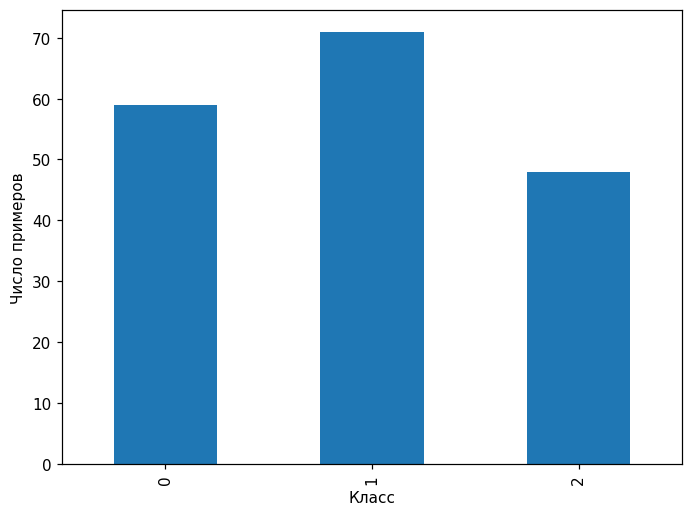

RandomForest
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



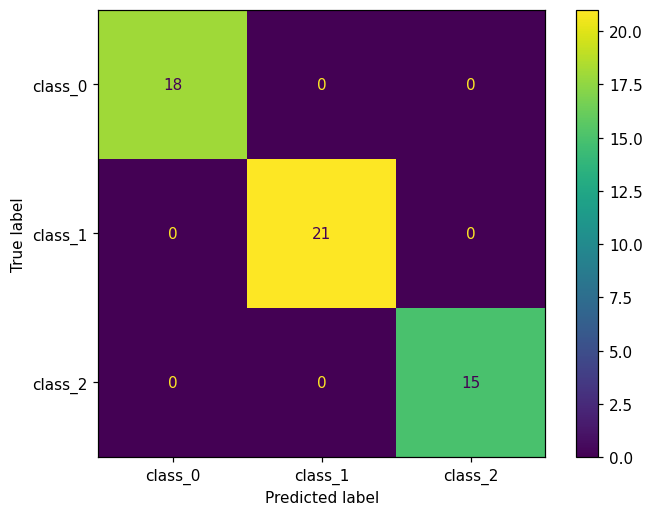

LogisticRegression
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



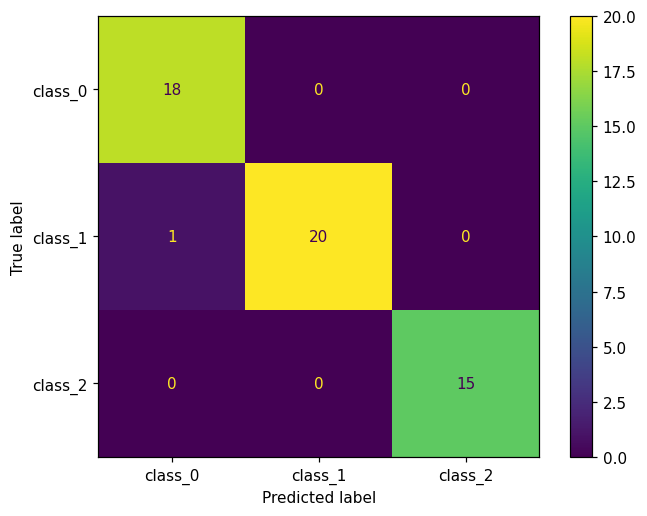

RandomForest balanced
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



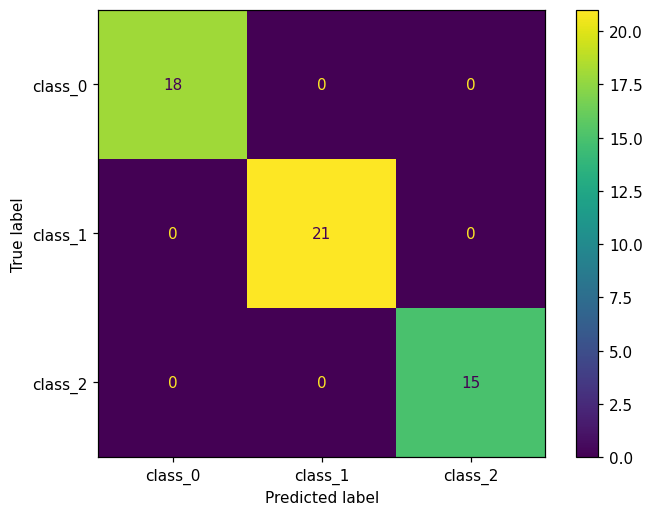

,Модель,Accuracy,Macro-F1
0,RandomForest,1.000000,1.000000
1,LogisticRegression,0.981481,0.982861
2,RandomForest balanced,1.000000,1.000000


RandomForest recall редкого класса 2 : 1.0
RandomForest balanced recall редкого класса 2 : 1.0
Наименьший recall логистической регрессии: class_1


In [2]:
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
wine = load_wine(as_frame=True)
X, y = wine.data, wine.target
print('Объектов:', len(X), 'Признаков:', X.shape[1])
print('Классы:', wine.target_names)
display(y.value_counts().sort_index().to_frame('Количество'))
y.value_counts().sort_index().plot.bar()
plt.xlabel('Класс'); plt.ylabel('Число примеров')
save_plot('p3_classes.png')
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
models = {
    'RandomForest': RandomForestClassifier(n_estimators=100,random_state=42),
    'LogisticRegression': Pipeline([('scaler',StandardScaler()),
        ('model',LogisticRegression(max_iter=2000,random_state=42))]),
    'RandomForest balanced': RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')}
rows = []; reports = {}
for number,(name,model) in enumerate(models.items()):
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    report=classification_report(y_test,pred,output_dict=True)
    reports[name]=report
    print(name)
    print(classification_report(y_test,pred,target_names=wine.target_names))
    rows.append({'Модель':name,'Accuracy':accuracy_score(y_test,pred),
                 'Macro-F1':f1_score(y_test,pred,average='macro')})
    ConfusionMatrixDisplay.from_predictions(y_test,pred,display_labels=wine.target_names)
    save_plot(f'p3_confusion_{number}.png')
results=pd.DataFrame(rows)
display(results)
results.to_csv(BASE/'results'/'practice3.csv',index=False)
rare_class=int(y.value_counts().idxmin())
for name in ['RandomForest','RandomForest balanced']:
    print(name, 'recall редкого класса',rare_class,':',reports[name][str(rare_class)]['recall'])
worst=min(range(3),key=lambda i:reports['LogisticRegression'][str(i)]['recall'])
print('Наименьший recall логистической регрессии:',wine.target_names[worst])
with open(BASE/'models'/'practice3.pkl','wb') as f:
    pickle.dump({'model':models['RandomForest'],'X_train':X_train,'X_test':X_test,
                 'y_train':y_train,'y_test':y_test},f)
save_json('practice3.json',{'class_counts':{str(k):int(v) for k,v in y.value_counts().items()},
                           'rare_class':rare_class,'reports':reports})

## Вывод
На этом разделении RandomForest справился со всеми тестовыми примерами. Редкий класс — class_2, его recall проверен отдельно. Балансировка не дала прироста на данном тесте. Для этого прототипа выбираю RandomForest, но результат 1,0 на небольшом тесте не означает безошибочную работу на любых новых винах. Для уверенной оценки нужна кросс-валидация, которую я использую в практике 4.

Самый редкий класс в полном наборе — class_2 (48 объектов), но он распознан без ошибок. У логистической регрессии минимальный recall у class_1: 20 из 21 ≈ 0,952; один объект принят за class_0. Поэтому редкий и хуже распознанный классы в данном эксперименте различаются. У RandomForest все классы на этом тесте имеют recall=1,0. Для работы с дисбалансом можно использовать веса классов или SMOTE только на train; следующие проверки находятся в практике 4.